# load example data

In [1]:
from rigid_invariant_NBLAST import rigid_invariant_nblast
import navis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

demo_neurons = navis.read_swc("./example_data/skeletons.zip")
demo_neurons.set_neuron_attributes("1 nanometer", "units") # the swc files are in nanometers
demo_neurons.convert_units("1 micrometer", inplace=True)
def assign_soma_pos(neuron):
    neuron.soma_pos = neuron.nodes[neuron.nodes["label"]=="soma"].iloc[0][["x","y","z"]].to_numpy().astype(float)
    neuron.soma_radius = neuron.nodes[neuron.nodes["label"]=="soma"].iloc[0]["radius"]
    return neuron
demo_neurons = demo_neurons.apply(assign_soma_pos) # add soma position and radius as attributes to each neuron

Importing:   0%|          | 0/30 [00:00<?, ?it/s]

convert_units:   0%|          | 0/30 [00:00<?, ?it/s]

Apply assign_soma_pos:   0%|          | 0/30 [00:00<?, ?it/s]

# set one neuron as the target

In [2]:
neuron_id = 0 # the target neuron 
res = rigid_invariant_nblast(query=demo_neurons, target=demo_neurons[neuron_id], template=demo_neurons["99511"][0])
skeletons_info = pd.read_csv("./example_data/skeletons_info.csv", index_col=0)
tmp = skeletons_info["neuron_class"].copy()
tmp.drop(tmp.index[neuron_id], inplace=True)  # drop the row corresponding to the target neuron
res.drop(res.index[neuron_id], inplace=True)
res.columns = ["Proposed"]
res["neuron_class"] = tmp.values
res.groupby("neuron_class")[["Proposed"]].mean()

Apply centering_neuron:   0%|          | 0/30 [00:00<?, ?it/s]

Apply <lambda>:   0%|          | 0/30 [00:00<?, ?it/s]

Dotprops:   0%|          | 0/30 [00:00<?, ?it/s]

Preparing:   0%|          | 0/1 [00:00<?, ?it/s]

NBlasting:   0%|          | 0/30 [00:00<?, ?it/s]

,Proposed
neuron_class,
NIN,0.538551
NPN,0.275410
PVIN,0.095967
PVPN,0.139393
SIN,0.473633
SPN,0.285993


# all by all

Apply centering_neuron:   0%|          | 0/30 [00:00<?, ?it/s]

Apply <lambda>:   0%|          | 0/30 [00:00<?, ?it/s]

Dotprops:   0%|          | 0/30 [00:00<?, ?it/s]

Preparing:   0%|          | 0/1 [00:00<?, ?it/s]

NBlasting:   0%|          | 0/30 [00:00<?, ?it/s]

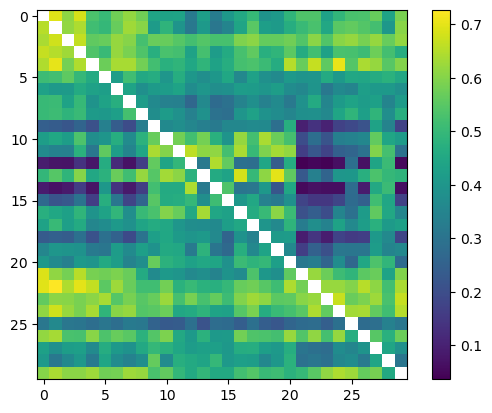

In [3]:
res_df = rigid_invariant_nblast(query=demo_neurons, template=demo_neurons["99511"][0], smat="v1") # first align all neurons to the template, then compute pairwise NBLAST scores
arr = res_df.values.copy()
np.fill_diagonal(arr, np.nan)
plt.imshow(arr, cmap="viridis")
plt.colorbar()

# with axon information

In [4]:
from rigid_invariant_NBLAST import rigid_invariant_nblast_compartment

neuron_id = 0
res_neurite, res_axon = rigid_invariant_nblast_compartment(query=demo_neurons, target=demo_neurons[neuron_id], template=demo_neurons["99511"][0])
skeletons_info = pd.read_csv("./example_data/skeletons_info.csv", index_col=0)
tmp = skeletons_info["neuron_class"].copy()
tmp.drop(tmp.index[neuron_id], inplace=True)  # drop the row corresponding to the target neuron
res = pd.concat([res_neurite, res_axon], axis=1)
res.drop(res.index[neuron_id], inplace=True)
res.columns = ["dendrite_similarity", "axon_similarity"]
res["neuron_class"] = tmp.values
res.groupby("neuron_class").mean()

Apply centering_neuron:   0%|          | 0/30 [00:00<?, ?it/s]

Apply <lambda>:   0%|          | 0/30 [00:00<?, ?it/s]

Dotprops:   0%|          | 0/30 [00:00<?, ?it/s]

Preparing:   0%|          | 0/1 [00:00<?, ?it/s]

NBlasting:   0%|          | 0/30 [00:00<?, ?it/s]

Dotprops:   0%|          | 0/30 [00:00<?, ?it/s]

Preparing:   0%|          | 0/1 [00:00<?, ?it/s]

NBlasting:   0%|          | 0/30 [00:00<?, ?it/s]

,dendrite_similarity,axon_similarity
neuron_class,,
NIN,0.486535,0.165131
NPN,0.385164,-0.575090
PVIN,0.213157,-0.463967
PVPN,0.253160,-0.511916
SIN,0.510001,-0.210368
SPN,0.356902,-0.477549


# test on 3 classes of PVPNs

In [5]:
demo_neurons = navis.read_swc("./example_data/PVPNs.zip")
demo_neurons.set_neuron_attributes("1 nanometer", "units")
demo_neurons.convert_units("1 micrometer", inplace=True)
demo_neurons = demo_neurons.apply(assign_soma_pos)

res_neurite, res_axon = rigid_invariant_nblast_compartment(query=demo_neurons, template="pairwise") # pairwise alignment

Importing:   0%|          | 0/9 [00:00<?, ?it/s]

convert_units:   0%|          | 0/9 [00:00<?, ?it/s]

Apply assign_soma_pos:   0%|          | 0/9 [00:00<?, ?it/s]

Apply centering_neuron:   0%|          | 0/9 [00:00<?, ?it/s]

Apply <lambda>:   0%|          | 0/9 [00:00<?, ?it/s]

...

Preparing:   0%|          | 0/1 [00:00<?, ?it/s]

NBlasting:   0%|          | 0/9 [00:00<?, ?it/s]

Dotprops:   0%|          | 0/9 [00:00<?, ?it/s]

Preparing:   0%|          | 0/1 [00:00<?, ?it/s]

NBlasting:   0%|          | 0/9 [00:00<?, ?it/s]

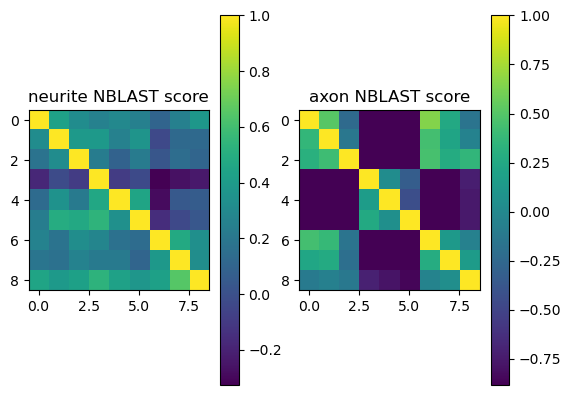

In [6]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.imshow(res_neurite.values, cmap="viridis")
plt.title("neurite NBLAST score")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(res_axon.values, cmap="viridis")
plt.title("axon NBLAST score")
plt.colorbar()